In [1]:
import pandas as pd
import numpy as np

# packages for modelling
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score
from scipy.stats import loguniform
import lightgbm as lgb

# packages for plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
path_data = "C:/Users/Lukas/OneDrive/Área de Trabalho/ml-project-data-science/ml-project-template/titanic-survival-prediction/data/01_raw/"
data_set = "water_potability.csv"

In [17]:
df = pd.read_csv(path_data + data_set)

In [18]:
# Dicionário com o mapeamento dos nomes atuais para os novos nomes em português
mapeamento_colunas = {
    'ph': 'ph',
    'Hardness': 'dureza',
    'Solids': 'solidos',
    'Chloramines': 'cloraminas',
    'Sulfate': 'sulfato',
    'Conductivity': 'condutividade',
    'Organic_carbon': 'carbono_organico',
    'Trihalomethanes': 'trihalometanos',
    'Turbidity': 'turbidez',
    'Potability': 'potabilidade_target'
}

# Aplicar a alteração no DataFrame
df = df.rename(columns=mapeamento_colunas)

# Confirmar as novas colunas
print(df.columns)

Index(['ph', 'dureza', 'solidos', 'cloraminas', 'sulfato', 'condutividade',
       'carbono_organico', 'trihalometanos', 'turbidez',
       'potabilidade_target'],
      dtype='str')


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ph                   2785 non-null   float64
 1   dureza               3276 non-null   float64
 2   solidos              3276 non-null   float64
 3   cloraminas           3276 non-null   float64
 4   sulfato              2495 non-null   float64
 5   condutividade        3276 non-null   float64
 6   carbono_organico     3276 non-null   float64
 7   trihalometanos       3114 non-null   float64
 8   turbidez             3276 non-null   float64
 9   potabilidade_target  3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [20]:
df.head(2)

,ph,dureza,solidos,cloraminas,sulfato,condutividade,carbono_organico,trihalometanos,turbidez,potabilidade_target
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.71608,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0


In [21]:
def distplots(df=df,n=8):
    cols = list(df.columns)
    fig, axes = plt.subplots(5, 2, figsize=(15,8))
    plt.tight_layout(pad=3)
    for col, ax in enumerate(axes.flatten()):
        if df[cols[col]].dtypes=='float64':
            sns.boxplot(x=df[cols[col]], ax=ax, color='darkcyan')
        if col>n:
            break;

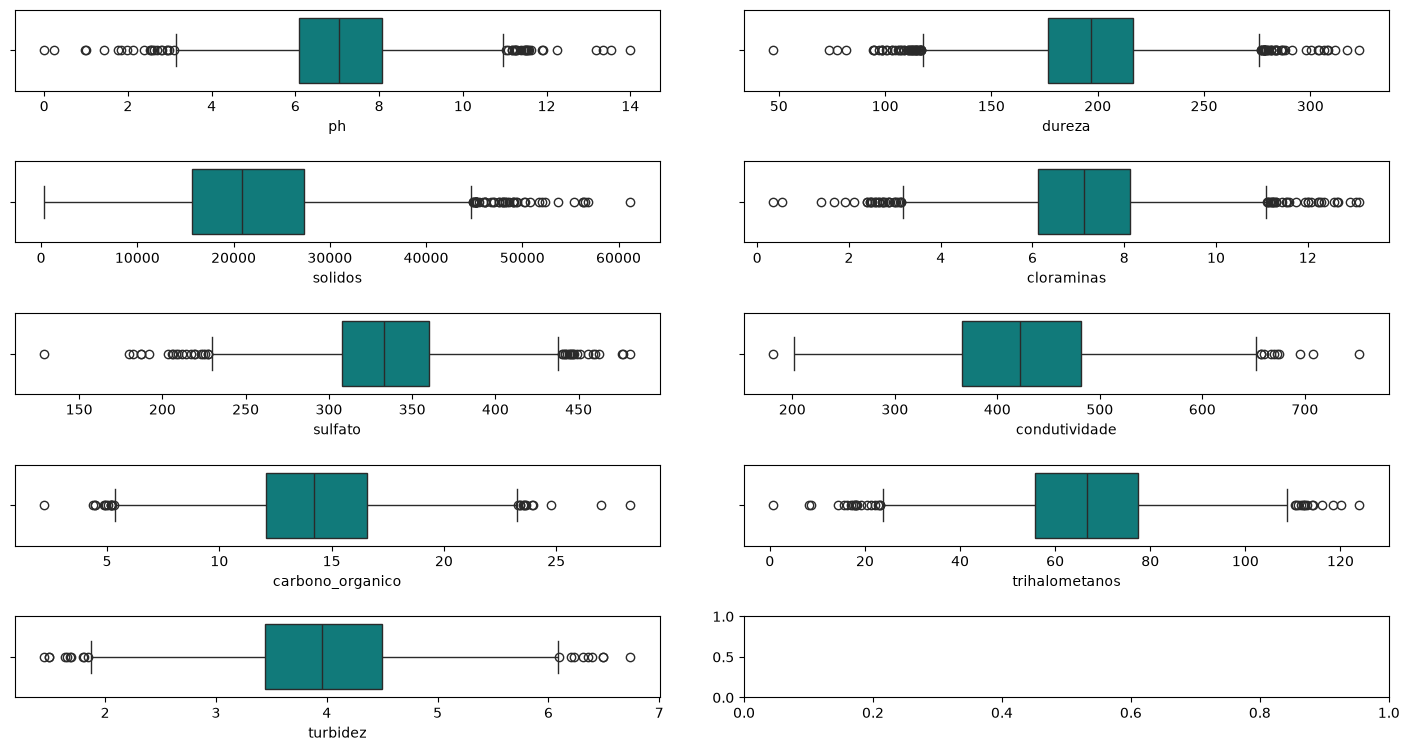

In [22]:
distplots(df=df,n=8)

In [23]:
df['potabilidade_target'].value_counts()

potabilidade_target
0    1998
1    1278
Name: count, dtype: int64